# POC — Architecture crossover in low-resource languages

Proof-of-concept for the proposal *"Where Attention Starts Winning."*

This notebook is **not** the experiment. It is a sequence of **gates**: each one tests a
specific project risk, and if a gate fails you know exactly which risk fired and what to
change before committing.

| Gate | Question | If it fails |
|---|---|---|
| 1 | Can we get enough text for each candidate language? | Swap languages, or lower the ladder |
| 2 | Does the tokenizer behave sensibly, and is fertility measurable? | Change vocab size / corpus |
| 3 | Does the matched-model training loop run and produce sane perplexities? | Fix before scaling |
| 4 | Can we see a crossover at miniature scale? | The full ladder may need wider rungs |

**Runtime:** roughly 25–40 min on a free T4 (most of it is streaming text, not training).
**Runtime → Change runtime type → GPU** before you start.

Everything here is deliberately small. The point is to prove the machinery and surface
surprises, not to produce a result worth quoting.

In [1]:
#@title Setup
%pip install -q -U datasets tokenizers 2>/dev/null

import os, time, math, json, random, itertools
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("gpu   :", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU. Runtime > Change runtime type > GPU.")

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(0)

torch 2.11.0+cu128 | device: cuda
gpu   : NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
#@title Configuration — edit here

# Candidate languages. FineWeb2 uses ISO-639-3 + script codes.
# Chosen to vary morphology and script, not just resource level.
CANDIDATES = {
    "swh_Latn": "Swahili   (Bantu, agglutinative, Latin)",
    "yor_Latn": "Yoruba    (Niger-Congo, tonal, Latin+diacritics)",
    "amh_Ethi": "Amharic   (Semitic, templatic, Ge'ez)",
    "npi_Deva": "Nepali    (Indo-Aryan, fusional, Devanagari)",
}

# The one language we actually train on in this POC (keep it to one; the full study loops).
POC_LANG = "swh_Latn"

# English control, for a fertility comparison and a sanity anchor.
CONTROL_LANG = "eng_Latn"

TARGET_CHARS   = 25_000_000   # how much raw text to pull per language (~5-7M tokens)
VOCAB_SIZE     = 8_000        # BPE vocab for the POC (full study uses a larger, fixed size)
SEQ_LEN        = 128
BATCH_SIZE     = 32
TRAIN_STEPS    = 1200         # FIXED optimization budget per rung -- see note below
EVAL_EVERY     = 200
LADDER         = [100_000, 300_000, 1_000_000, 3_000_000]   # tokens per rung

# Why a fixed STEP budget rather than a fixed epoch count: in a data-scale study, "10 epochs"
# gives the 3M rung 30x more gradient updates than the 100k rung, so data scale and
# optimization budget get confounded. Fixing steps isolates the variable we care about.
print(f"Each run sees {TRAIN_STEPS * BATCH_SIZE * SEQ_LEN / 1e6:.1f}M tokens of gradient "
      f"updates regardless of rung size.")

Each run sees 4.9M tokens of gradient updates regardless of rung size.


---
## Gate 1 — Is there enough text?

This is the highest-probability failure in the whole project, and it costs nothing to check.

We stream from FineWeb2 rather than downloading: the full dataset is enormous, but streaming
lets us pull a bounded number of characters and stop. The notebook falls back to Wikipedia
if a FineWeb2 config is unavailable.

**What to look for:** every language you intend to use should reach `TARGET_CHARS` without
the stream running dry, and the throughput should be fast enough that collecting the real
corpus later is practical.

In [3]:
#@title Probe available FineWeb2 configs
from datasets import get_dataset_config_names

FINEWEB = "HuggingFaceFW/fineweb-2"
available = None
try:
    t0 = time.time()
    available = set(get_dataset_config_names(FINEWEB))
    print(f"FineWeb2 exposes {len(available)} configs ({time.time()-t0:.0f}s)")
except Exception as e:
    print("Could not list FineWeb2 configs:", repr(e))

if available:
    for code_, desc in {**CANDIDATES, CONTROL_LANG: "English (control)"}.items():
        # configs are sometimes suffixed (e.g. '<lang>_removed'); match on the stem
        hits = sorted(c for c in available if c.split("_removed")[0] == code_)
        print(f"  {code_:<10} {desc:<45} {'OK ' + str(hits[:2]) if hits else 'NOT FOUND'}")
    print("\nIf a language is NOT FOUND, check the code against the config list:")
    print("  sorted(c for c in available if c.startswith('yor'))")

FineWeb2 exposes 1870 configs (3s)
  swh_Latn   Swahili   (Bantu, agglutinative, Latin)       OK ['swh_Latn']
  yor_Latn   Yoruba    (Niger-Congo, tonal, Latin+diacritics) OK ['yor_Latn']
  amh_Ethi   Amharic   (Semitic, templatic, Ge'ez)         OK ['amh_Ethi']
  npi_Deva   Nepali    (Indo-Aryan, fusional, Devanagari)  OK ['npi_Deva']
  eng_Latn   English (control)                             NOT FOUND

If a language is NOT FOUND, check the code against the config list:
  sorted(c for c in available if c.startswith('yor'))


In [4]:
#@title Stream text for one language and measure volume
from datasets import load_dataset

def stream_text(lang_code, target_chars=TARGET_CHARS, max_seconds=240, verbose=True):
    '''Pull up to target_chars of text. Tries FineWeb2, falls back to Wikipedia.

    Returns (text, source_name). Raises RuntimeError if no source works.
    '''
    attempts = [
        ("fineweb-2", lambda: load_dataset(FINEWEB, name=lang_code, split="train",
                                           streaming=True)),
    ]
    wiki_code = {"swh_Latn": "sw", "yor_Latn": "yo", "amh_Ethi": "am",
                 "npi_Deva": "ne", "eng_Latn": "en"}.get(lang_code)
    if wiki_code:
        attempts.append(("wikipedia", lambda: load_dataset(
            "wikimedia/wikipedia", f"20231101.{wiki_code}", split="train", streaming=True)))

    last_err = None
    for name, opener in attempts:
        try:
            ds = opener()
            buf, n, t0 = [], 0, time.time()
            for rec in ds:
                txt = rec.get("text") or ""
                if not txt:
                    continue
                buf.append(txt); n += len(txt)
                if n >= target_chars or time.time() - t0 > max_seconds:
                    break
            if n < target_chars * 0.05:
                raise RuntimeError(f"only {n:,} chars available")
            if verbose:
                print(f"  [{name}] {n:,} chars in {time.time()-t0:.0f}s"
                      f"{'  (TRUNCATED BY TIME LIMIT)' if n < target_chars else ''}")
            return "\n".join(buf), name
        except Exception as e:
            last_err = e
            if verbose:
                print(f"  [{name}] failed: {repr(e)[:120]}")
    raise RuntimeError(f"no source worked for {lang_code}: {last_err}")

print(f"Streaming {POC_LANG} ...")
text_target, src_target = stream_text(POC_LANG)
print(f"Streaming {CONTROL_LANG} (control, smaller pull) ...")
text_ctrl, src_ctrl = stream_text(CONTROL_LANG, target_chars=5_000_000)

print("\n--- sample of target-language text (READ THIS) ---")
print(text_target[:600].replace("\n", " ")[:600])
print("\nIf that is not readable prose in the language you expect, stop and fix the source "
      "before training on it.")

Streaming swh_Latn ...
  [fineweb-2] 25,003,035 chars in 3s
Streaming eng_Latn (control, smaller pull) ...
  [fineweb-2] failed: ValueError("BuilderConfig 'eng_Latn' not found. Available: ['aai_Latn', 'aak_Latn', 'aau_Latn', 'aaz_Latn', 'aba_Latn', 


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

  [wikipedia] 5,007,358 chars in 2s

--- sample of target-language text (READ THIS) ---
Let your graceful words fly out into the World, carried on winds of courage, imagination and joy. Let them inspire others to step into action Toba, Sikujua CV inapima IQ ! Huyu ndiye aliyeenda shule mwenye wageni majununi, wenzangunamie kina Maimuna sijui watakuwaje. Kwa wale mnaotaka kuiona picha yake nendeni kwenye hii site. http://www.darhotwire.com/maisha/new...a_na_mpya.html au http://www.globalpublisherstz.com Alafu kwenye tafuta andika manka mushi. Kuna picha kama 3 nzuri hivi alizopiga akionekana mwili mzima. Sasa waungwana niambieni mnamuonaje? Ni mzuri au vipi? Kwa macho haonekani ka

If that is not readable prose in the language you expect, stop and fix the source before training on it.


---
## Gate 2 — Tokenizer and fertility

Fertility (subword tokens per whitespace word) is the candidate predictor in the proposal,
and it is nearly free to measure. It is also a good corpus sanity check: wildly high
fertility usually means the corpus is not the language you think it is, or the script is
being mangled.

In [5]:
#@title Train a BPE tokenizer and measure fertility
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

def train_bpe(text, vocab_size=VOCAB_SIZE, chunk=200_000):
    tok = Tokenizer(models.BPE(unk_token=None))
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, show_progress=False,
                                  initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
                                  special_tokens=["<pad>", "<unk>"])
    tok.train_from_iterator((text[i:i+chunk] for i in range(0, len(text), chunk)), trainer)
    return tok

def fertility(tok, text, n_chars=300_000):
    sample = text[:n_chars]
    n_words = len(sample.split())
    n_tokens = len(tok.encode(sample).ids)
    return n_tokens / max(n_words, 1)

t0 = time.time()
tok_target = train_bpe(text_target)
tok_ctrl   = train_bpe(text_ctrl)
print(f"trained two {VOCAB_SIZE}-token BPE vocabularies in {time.time()-t0:.0f}s\n")

f_t = fertility(tok_target, text_target)
f_c = fertility(tok_ctrl,   text_ctrl)
print(f"fertility  {POC_LANG:<10} {f_t:.2f} tokens/word")
print(f"fertility  {CONTROL_LANG:<10} {f_c:.2f} tokens/word")
print(f"ratio      {f_t / f_c:.2f}x")
print("\nRoundtrip check (should match the input):")
probe = text_target[:160].replace("\n", " ")
print("  in :", probe)
print("  out:", tok_target.decode(tok_target.encode(probe).ids))

trained two 8000-token BPE vocabularies in 3s

fertility  swh_Latn   1.64 tokens/word
fertility  eng_Latn   1.60 tokens/word
ratio      1.02x

Roundtrip check (should match the input):
  in : Let your graceful words fly out into the World, carried on winds of courage, imagination and joy. Let them inspire others to step into action Toba, Sikujua CV i
  out:  Let your graceful words fly out into the World, carried on winds of courage, imagination and joy. Let them inspire others to step into action Toba, Sikujua CV i


In [6]:
#@title Encode the corpus into a flat token array
ids = np.array(tok_target.encode(text_target).ids, dtype=np.uint16)
print(f"{len(ids):,} tokens encoded  ({len(ids)/1e6:.2f}M)")

max_rung = max(LADDER)
if len(ids) < max_rung * 1.15:
    print(f"\nWARNING: only {len(ids):,} tokens but the top rung needs ~{int(max_rung*1.15):,}.")
    LADDER = [r for r in LADDER if r * 1.15 <= len(ids)]
    print(f"Ladder reduced to: {LADDER}")

VAL_TOKENS = 200_000
val_ids = ids[-VAL_TOKENS:]      # held out once, shared by every rung so runs are comparable
pool_ids = ids[:-VAL_TOKENS]
print(f"train pool {len(pool_ids):,} | val {len(val_ids):,} (shared across all rungs)")

6,064,250 tokens encoded  (6.06M)
train pool 5,864,250 | val 200,000 (shared across all rungs)


---
## Gate 3 — Matched models and the training loop

Two design decisions mirror the full study so that this POC is a true miniature:

**Backbone parameter matching.** Both families carry an identical tied embedding table, so
matching on *total* parameters would let the embedding dominate and hide the architectural
comparison. We match on everything except the embeddings, and auto-tune the LSTM hidden
size to hit the transformer's backbone count rather than hardcoding it.

**Windowed streaming with a fixed step budget.** Training draws random windows; validation
walks non-overlapping windows in fixed order so every token is scored exactly once and two
checkpoints are exactly comparable.

In [7]:
#@title Model definitions
class LstmLM(nn.Module):
    def __init__(self, vocab, d=256, hidden=460, layers=2, dropout=0.2):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.drop = nn.Dropout(dropout)
        # separate single-layer LSTMs with explicit dropout between them (identical semantics
        # to a multi-layer nn.LSTM with dropout=, but avoids a cuDNN dropout-state issue)
        self.layers = nn.ModuleList([nn.LSTM(d if i == 0 else hidden, hidden, batch_first=True)
                                     for i in range(layers)])
        self.proj = nn.Linear(hidden, d, bias=False)
        self.head = nn.Linear(d, vocab, bias=False)
        self.head.weight = self.tok.weight          # tied

    def forward(self, x):
        h = self.drop(self.tok(x))
        for i, l in enumerate(self.layers):
            h, _ = l(h)
            if i < len(self.layers) - 1:
                h = self.drop(h)
        return self.head(self.proj(self.drop(h)))


class Attn(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.h, self.p = heads, dropout
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.proj = nn.Linear(d, d)

    def forward(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(x).chunk(3, -1)
        q, k, v = (t.view(B, T, self.h, D // self.h).transpose(1, 2) for t in (q, k, v))
        o = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                           dropout_p=self.p if self.training else 0.0)
        return self.proj(o.transpose(1, 2).contiguous().view(B, T, D))


class Block(nn.Module):
    def __init__(self, d, heads, ffn, dropout):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = Attn(d, heads, dropout)
        self.mlp = nn.Sequential(nn.Linear(d, ffn), nn.GELU(), nn.Dropout(dropout),
                                 nn.Linear(ffn, d), nn.Dropout(dropout))

    def forward(self, x):
        x = x + self.attn(self.n1(x))
        return x + self.mlp(self.n2(x))


class GPTLM(nn.Module):
    def __init__(self, vocab, seq_len, d=256, heads=4, layers=4, ffn=1024, dropout=0.1):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(seq_len, d)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[Block(d, heads, ffn, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.head.weight = self.tok.weight          # tied
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B, T = x.shape
        h = self.drop(self.tok(x) + self.pos(torch.arange(T, device=x.device)))
        return self.head(self.norm(self.blocks(h)))


def backbone_params(m):
    skip = {id(m.tok.weight)} | ({id(m.pos.weight)} if hasattr(m, "pos") else set())
    seen, tot = set(), 0
    for p in m.parameters():
        if id(p) not in skip and id(p) not in seen and p.requires_grad:
            seen.add(id(p)); tot += p.numel()
    return tot


def matched_lstm_hidden(vocab, target_backbone, lo=256, hi=768):
    '''Pick the LSTM hidden size whose backbone is closest to the transformer's.'''
    # backbone excludes the (tied) embedding, so vocab is irrelevant here -- use a tiny one
    best = min(range(lo, hi + 1, 4),
               key=lambda h: abs(backbone_params(LstmLM(16, hidden=h)) - target_backbone))
    return best

V = tok_target.get_vocab_size()
_gpt = GPTLM(V, SEQ_LEN)
GPT_BB = backbone_params(_gpt)
H = matched_lstm_hidden(V, GPT_BB)
LSTM_BB = backbone_params(LstmLM(V, hidden=H))
print(f"vocab {V}")
print(f"GPT  backbone {GPT_BB:,}")
print(f"LSTM backbone {LSTM_BB:,}  (hidden={H}, auto-tuned)")
print(f"mismatch {abs(GPT_BB-LSTM_BB)/GPT_BB*100:.1f}%  -- want < ~3%")
del _gpt

vocab 8000
GPT  backbone 3,156,480
LSTM backbone 3,135,360  (hidden=460, auto-tuned)
mismatch 0.7%  -- want < ~3%


In [8]:
#@title Data windowing + train/eval loop
class TokenStream:
    '''Whole split resident on GPU; batches are one gather, no DataLoader.'''
    def __init__(self, arr, device, seq_len):
        self.t = torch.from_numpy(arr.astype(np.int64)).to(device)
        self.n, self.seq_len, self.device = len(self.t), seq_len, device

    def _gather(self, starts):
        pos = starts.view(-1, 1) + torch.arange(self.seq_len + 1, device=self.device)
        w = self.t[pos]
        return w[:, :-1], w[:, 1:]

    def random_batch(self, bs, gen):
        s = torch.randint(0, self.n - self.seq_len - 1, (bs,), device=self.device, generator=gen)
        return self._gather(s)

    def sequential_batches(self, bs):
        starts = torch.arange(0, self.n - self.seq_len - 1, self.seq_len, device=self.device)
        for i in range(0, len(starts), bs):
            yield self._gather(starts[i:i + bs])


@torch.no_grad()
def evaluate(model, stream, bs=64):
    model.eval()
    tot, ntok = 0.0, 0
    for x, y in stream.sequential_batches(bs):
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
            loss = F.cross_entropy(model(x).float().reshape(-1, model.head.out_features),
                                   y.reshape(-1))
        tot += loss.item() * y.numel(); ntok += y.numel()
    model.train()
    return math.exp(min(tot / ntok, 20))


def run(arch, n_tokens, seed=0, steps=TRAIN_STEPS, log=True):
    set_seed(seed)
    gen = torch.Generator(device=DEVICE); gen.manual_seed(seed)
    train = TokenStream(pool_ids[:n_tokens], DEVICE, SEQ_LEN)
    val   = TokenStream(val_ids, DEVICE, SEQ_LEN)

    model = (GPTLM(V, SEQ_LEN) if arch == "gpt" else LstmLM(V, hidden=H)).to(DEVICE)
    lr = 3e-4 if arch == "gpt" else 1e-3      # family-appropriate recipes
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps,
                                                pct_start=0.1)
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    best, t0 = float("inf"), time.time()
    for step in range(1, steps + 1):
        x, y = train.random_batch(BATCH_SIZE, gen)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
            loss = F.cross_entropy(model(x).reshape(-1, V), y.reshape(-1))
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        if step % EVAL_EVERY == 0 or step == steps:
            ppl = evaluate(model, val)
            best = min(best, ppl)
            if log:
                print(f"    step {step:>5}  val_ppl {ppl:8.2f}  best {best:8.2f}")
    if log:
        print(f"    done in {time.time()-t0:.0f}s")
    return best

---
## Gate 4 — The miniature ladder

Both families at every rung. This is the whole experiment in miniature.

**What counts as success here is that the machinery works and the numbers are sane** —
perplexities in a plausible range, decreasing with more data, no NaNs. Seeing an actual
crossover would be a bonus; at this scale and with one seed, do not treat the crossing
point as a result.

In [9]:
#@title Run the ladder
results = {}
for arch in ["lstm", "gpt"]:
    for n in LADDER:
        print(f"\n[{arch}] {n:,} tokens")
        results[(arch, n)] = run(arch, n)

print("\n\n=== best validation perplexity (lower is better) ===")
print(f"{'tokens':>12} {'LSTM':>10} {'GPT':>10}   winner")
for n in LADDER:
    l, g = results[("lstm", n)], results[("gpt", n)]
    print(f"{n:>12,} {l:>10.2f} {g:>10.2f}   {'LSTM' if l < g else 'GPT'}")


[lstm] 100,000 tokens
    step   200  val_ppl  1778.17  best  1778.17
    step   400  val_ppl  2694.49  best  1778.17
    step   600  val_ppl  4134.51  best  1778.17
    step   800  val_ppl  5763.05  best  1778.17
    step  1000  val_ppl  6732.61  best  1778.17
    step  1200  val_ppl  6963.15  best  1778.17
    done in 11s

[lstm] 300,000 tokens
    step   200  val_ppl  1306.13  best  1306.13
    step   400  val_ppl   989.38  best   989.38
    step   600  val_ppl   883.82  best   883.82
    step   800  val_ppl   842.00  best   842.00
    step  1000  val_ppl   819.63  best   819.63
    step  1200  val_ppl   820.34  best   819.63
    done in 10s

[lstm] 1,000,000 tokens
    step   200  val_ppl  1168.49  best  1168.49
    step   400  val_ppl   854.83  best   854.83
    step   600  val_ppl   691.78  best   691.78
    step   800  val_ppl   607.91  best   607.91
    step  1000  val_ppl   578.50  best   578.50
    step  1200  val_ppl   573.56  best   573.56
    done in 10s

[lstm] 3,000,000

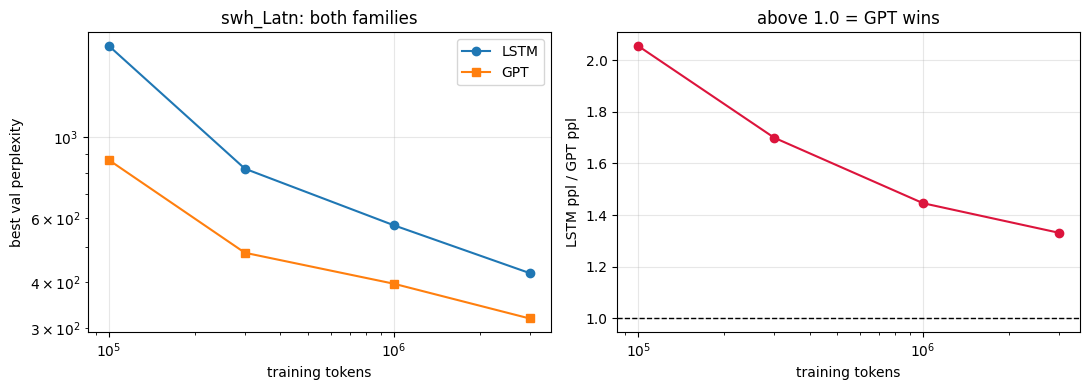

No flip inside this ladder -- GPT wins throughout. For the real study, extend the ladder in that direction.


In [10]:
#@title Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
xs = LADDER
ax[0].plot(xs, [results[("lstm", n)] for n in xs], "o-", label="LSTM")
ax[0].plot(xs, [results[("gpt", n)] for n in xs], "s-", label="GPT")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("training tokens"); ax[0].set_ylabel("best val perplexity")
ax[0].set_title(f"{POC_LANG}: both families"); ax[0].legend(); ax[0].grid(alpha=.3)

ratio = [results[("lstm", n)] / results[("gpt", n)] for n in xs]
ax[1].plot(xs, ratio, "o-", color="crimson")
ax[1].axhline(1.0, ls="--", c="k", lw=1)
ax[1].set_xscale("log")
ax[1].set_xlabel("training tokens"); ax[1].set_ylabel("LSTM ppl / GPT ppl")
ax[1].set_title("above 1.0 = GPT wins"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

crossed = [i for i in range(1, len(xs)) if (ratio[i-1] < 1) != (ratio[i] < 1)]
if crossed:
    i = crossed[0]
    print(f"Sign flip between {xs[i-1]:,} and {xs[i]:,} tokens.")
else:
    print(f"No flip inside this ladder -- {'GPT' if ratio[0] > 1 else 'LSTM'} wins throughout. "
          f"For the real study, extend the ladder in that direction.")

---
## What this told you

Work through these before writing any more code:

1. **Did every candidate language pass Gate 1?** If any were NOT FOUND or ran dry, fix the
   language set now — it propagates into everything.
2. **Was the decoded sample readable prose?** Low-resource web text is frequently
   misidentified. A corpus that is 30% English will quietly invalidate the comparison.
3. **What was the fertility ratio versus English?** If it is near 1.0 for every candidate,
   the proposal's main predictor has no variance and you should reconsider it.
4. **Are the perplexities plausible and falling with data?** Flat or exploding curves mean a
   bug, not a finding.
5. **How long did the 3M-token rung take?** Multiply by (languages x rungs x archs x seeds)
   to sanity-check the full study against your calendar.

### What to change for the real study

- Raise `TRAIN_STEPS` substantially — 1200 steps is nowhere near convergence, and a
  data-scale comparison is only fair if both families have run out of room.
- Three seeds at rungs adjacent to any observed crossover.
- Add the capacity controls (a larger LSTM, a larger GPT) at those same rungs. Without them
  a reviewer will ask whether the LSTM was simply too small.
- Loop over all languages, and add English as a control on the identical ladder.